# Chuẩn hóa bệnh tiểu đường

## 1. Định nghĩa vấn đề
+ **Mô tả :**
    + Bộ dữ liệu bao gồm 768 mẫu từ 768 hồ sơ của các bệnh nhân có hoặc không mẵ bệnh tiểu đường.
    + Mỗi mẫu bao gồm các đặc điểm vật lý (tuổi tác, số lần mang thai,..) và các đặc trưng sinh lý cơ thể (tỉ lệ BMI của cơ thể, mức đường huyết Glucozo, mức Insulin, ...).
+ **Dữ liệu đầu vào :**
    + `Pregnancies`: Số lần mang thai
    + `Glucose`: Mức đường huyết
    + `BloodPressure`: Huyết áp
    + `SkinThickness`: Độ dày da
    + `Insulin`: Mức insulin
    + `BMI`: Chỉ số khối cơ thể
    + `DiabetesPedigreeFunction`: Chỉ số di truyền tiểu đường
    + `Age`: Tuổi
+ **Kết quả :** Bệnh nhân có hoặc không mắc bệnh tiểu đường.

## 2. Chuẩn bị vấn đề

### 2.1 Khai báo thư viện

In [30]:
import os, sys
from IPython import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

%matplotlib inline
import warnings
warnings.filterwarnings('ignore')


### 2.2 Nạp dữ liệu 

In [31]:
data_path = '../data/pima.csv'
data_names = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]
df = pd.read_csv(data_path, names=data_names)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 3. Phân tích khám phá dữ liệu (EDA)

### 3.1 Thống kê mô tả

#### a) Hiển thị một số thông tin và dữ liệu 
+ Số dòng, số cột của dữ liệu
+ Kiểu dữ liệu của từng cột
+ 5 dòng đầu và 5 dòng cuối của bảng dữ liệu
+ Thông tin chung về dữ liệu

In [32]:
print (f'Shape: {df.shape}')  
print (f'Data types: \n{df.dtypes}')
display.display(df.head())
display.display(df.tail())
df.info()

Shape: (768, 9)
Data types: 
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


**Nhận xét**
- Dữ liệu có 768 dòng và 9 cột 
- Tất cả các cột đều có kiểu dữ liệu số (`int64` hoặc `float64`)


#### b) Kiếm tra tính toàn vẹn của dữ liệu
- Hiển thị dữ liệu bị trùng lặp
- Hiển thị dữ liệu tồn tại giá trị Null, NaN

In [33]:
print('-'*3, 'Checking duplicated', '-'*3)
n_duplicated = df.duplicated().sum()
display.display(df[df.duplicated()])
if n_duplicated>0:
    print(" Số dòng loại bỏ: %d"%(len(df[df.duplicated(keep = "first")])))
    display.display(df[df.duplicated(keep = "first")])

--- Checking duplicated ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


- Kiểm tra các cột có giá trị 0 bất thường

In [34]:
zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[zero_columns] = df[zero_columns].replace(0, np.nan)

In [35]:
print('-'*3, 'Checking Null', '-'*3)
display.display(df.isnull().sum())


--- Checking Null ---


Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [36]:
print('-'*3, 'Checking NaN', '-'*3)
display.display(df.isna().sum())

--- Checking NaN ---


Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

**Nhận xét**
- Dữ liệu không có giá trị rỗng, không hợp lệ
- Dữ liệu không có dòng bị trùng

#### c) Các tính chất thống kê trên dữ liệu số
- Count, Mean, Standard Deviation, Mininmum value
- 25th Percentile, 50th Percentile (Median), 75th Percentile, Maximum Value

In [37]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,763.0,121.686763,30.535641,44.000,99.00000,117.0000,141.00000,199.00
BloodPressure,733.0,72.405184,12.382158,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,541.0,29.153420,10.476982,7.000,22.00000,29.0000,36.00000,99.00
Insulin,394.0,155.548223,118.775855,14.000,76.25000,125.0000,190.00000,846.00
BMI,757.0,32.457464,6.924988,18.200,27.50000,32.3000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


Phương thức này cho ta một cái nhìn tổng quan về dữ liệu trong dataset như:<br>
&#8226;&nbsp;&nbsp; `Count` : Đếm số lượng dòng có thông tin của 1 cột.<br>
&#8226;&nbsp;&nbsp; `mean` : Giá trị trung bình của 1 cột.<br>
&#8226;&nbsp;&nbsp; `std` : Độ lệch chuẩn của cột đó.<br>
&#8226;&nbsp;&nbsp; `min` : Giá trị nhỏ nhất của cột.<br>
&#8226;&nbsp;&nbsp; `25%, 50%, 75%` : Đây là tứ phân vị (quartiles) của cột, tìm giá trị nhỏ hơn hoặc bằng ở từng phân vị.<br>
&#8226;&nbsp;&nbsp; `max` : Giá trị lớn nhất trong cột.<br>

#### e) Mối tương quan giữa các tính chất
Sự tương quan thể hiện mối quan hệ giữa hai biến và cách chúng có thể có hoặc không cùng nhau thay đổi.

Phương pháp phổ biến nhất tính tương quan là Pearson's Correlation Coeficient.

- Tương quan -1 hoặc 1: mối tương quan âm hoặc tương quan dương đầy đủ tương ứng.
- Tương quan 0: không tương quan ở tất cả
$$
r = \frac{\sum_{i=1}^n{\left(x_i - \hat{x}\right)\left(y_i - \hat{y}\right)}}{\sqrt{\sum_{i=1}^n{\left(x_i - \hat{x}\right)^2}\sum_{i=1}^n{\left(y_i - \hat{y}\right)^2}}}
$$


In [38]:
correlations = df.corr(method = 'pearson')
correlations

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.128135,0.214178,0.100239,0.082171,0.021719,-0.033523,0.544341,0.221898
Glucose,0.128135,1.000000,0.223192,0.228043,0.581186,0.232771,0.137246,0.267136,0.494650
BloodPressure,0.214178,0.223192,1.000000,0.226839,0.098272,0.289230,-0.002805,0.330107,0.170589
SkinThickness,0.100239,0.228043,0.226839,1.000000,0.184888,0.648214,0.115016,0.166816,0.259491
Insulin,0.082171,0.581186,0.098272,0.184888,1.000000,0.228050,0.130395,0.220261,0.303454
BMI,0.021719,0.232771,0.289230,0.648214,0.228050,1.000000,0.155382,0.025841,0.313680
DiabetesPedigreeFunction,-0.033523,0.137246,-0.002805,0.115016,0.130395,0.155382,1.000000,0.033561,0.173844
Age,0.544341,0.267136,0.330107,0.166816,0.220261,0.025841,0.033561,1.000000,0.238356
Outcome,0.221898,0.494650,0.170589,0.259491,0.303454,0.313680,0.173844,0.238356,1.000000


**Nhận xét**
- Biến có ảnh hưởng mạnh nhất đến biến mục tiêu Outcome: Glucose (0.466)
- Các cặp tính chất có tinhs tương quan tương đối cao:
    - Age - Pregnancies: 0.544
- Các yếu tố phụ có ảnh hưởng: BMI, Age, Pregnancies
- Các mối quan hệ giữa các biến độc lập nhìn chung thấp

### 3.2 Hiển thị dữ liệu
#### a) Hiển thị trên từng tính chất đơn

##### Biểu đồ Histogram
Biểu đồ **Histogram** được sử dụng để phân tích phân phối của từng biến **(univariate analysis)**. Nhờ tính trực quan, **Histogram** giúp quan sát nhanh đặc điểm dữ liệu, như xu hướng phân bố, độ tập trung, và sự xuất hiện của các giá trị ngoại lai.

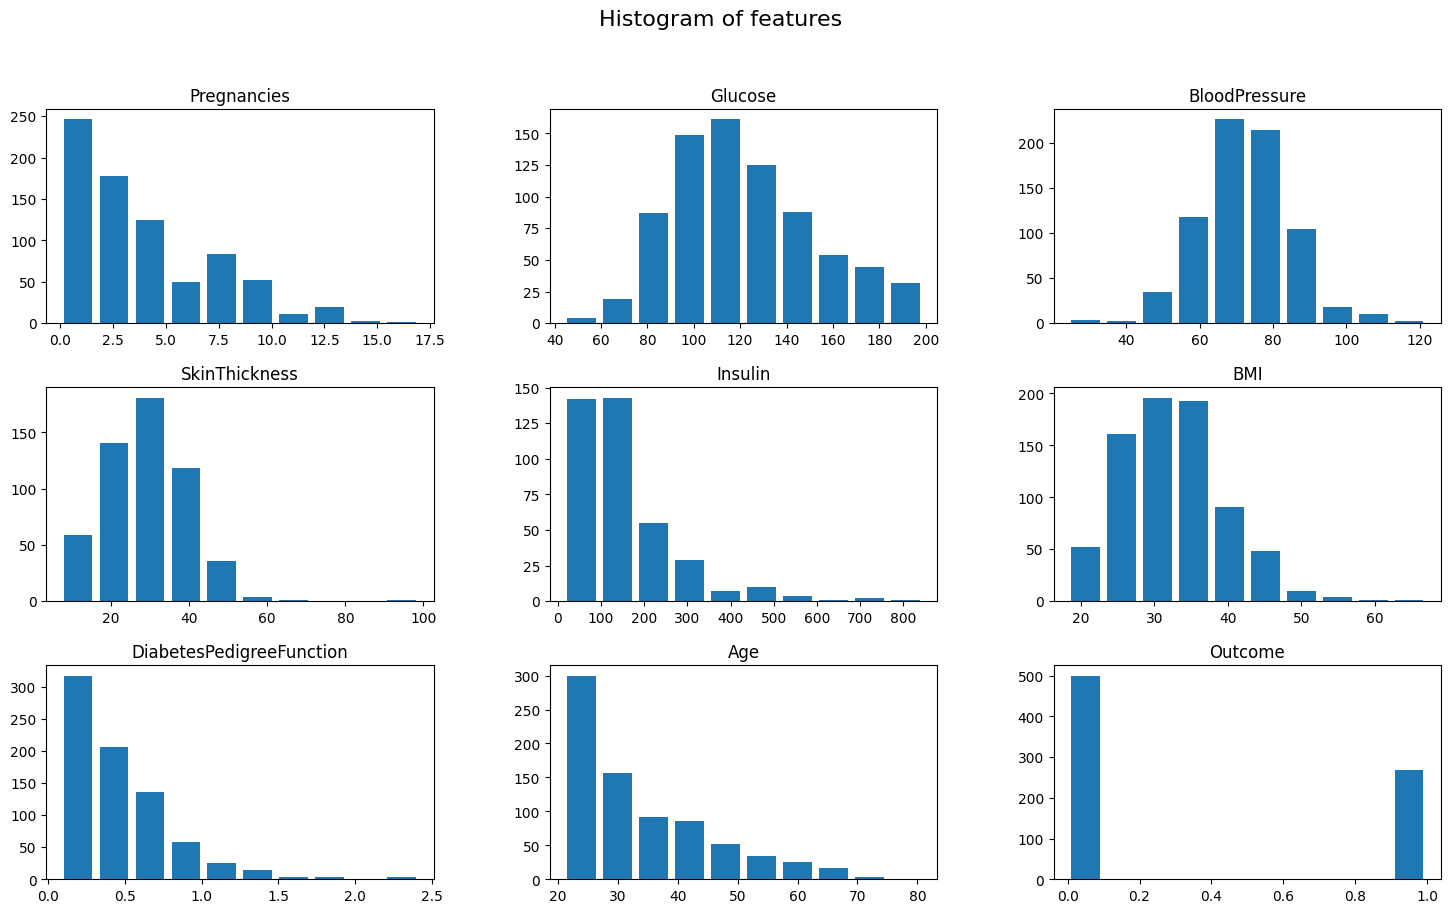

In [39]:
df.hist(figsize=(18,10), grid=False, rwidth=0.8, zorder=2)
plt.suptitle('Histogram of features', fontsize=16)
plt.show()

**Nhận xét:**

&#8226;&nbsp;&nbsp; `Pregnancies`: số lần mang thai chủ yếu tập trung ở mức thấp (0–3 lần), ít người có trên 10 lần. Nhưng bên cạnh đó có 1 số người có đến 18 (lệch khá lớn).<br>
&#8226;&nbsp;&nbsp; `Glucose`: phân bố gần chuẩn, tập trung nhiều trong khoảng 100–150, tức mức đường huyết trung bình đến hơi cao. Có vài giá trị rất thấp hoặc rất cao → outlier hoặc giá trị bất thường<br>
&#8226;&nbsp;&nbsp; `BloodPressure`: đa số bệnh nhân có huyết áp trong khoảng 60–80. Có vài giá trị thấp bất thường (gần 0) → dữ liệu thiếu hoặc lỗi<br>
&#8226;&nbsp;&nbsp; `SkinThickness` và test (insulin test): phân phối lệch phải mạnh, nhiều giá trị bằng 0.<br>
&#8226;&nbsp;&nbsp; `BMI`: tập trung quanh 30–35, gần giống phân phối chuẩn.<br>
&#8226;&nbsp;&nbsp; `DiabetesPedigreeFunction`: phần lớn nhỏ hơn 1, chỉ vài trường hợp cao bất thường.<br>
&#8226;&nbsp;&nbsp; `Age `: tập trung ở nhóm 20–40 tuổi, ít bệnh nhân lớn tuổi.<br>
&#8226;&nbsp;&nbsp; `Outcome` (kết quả tiểu đường): dữ liệu nhị phân, cho thấy số người không mắc bệnh nhiều hơn người mắc bệnh.

##### Box plot
Biểu đồ Box Plot thường dùng để mô tả phân phối dữ liệu và phát hiện các giá trị ngoại lai(outliers).<br>
Cụ thể mỗi Box Plot thể hiện:<br>
&#8226;&nbsp;&nbsp; *Đường giữa* (median - trung vị) : đường ngang trong hộp.<br>
&#8226;&nbsp;&nbsp; *Hộp* (box) : từ Q1 (25%) đến Q3(75%) &rarr; vùng phân vị giữa.<br>
&#8226;&nbsp;&nbsp; *Whiskers* (râu): khoảng giá trị trong phạm vi [Q1 – 1.5 * IQR, Q3 + 1.5 * IQR].<br>
&#8226;&nbsp;&nbsp; *Các điểm tròn*: giá trị ngoại lai (outliers).<br>

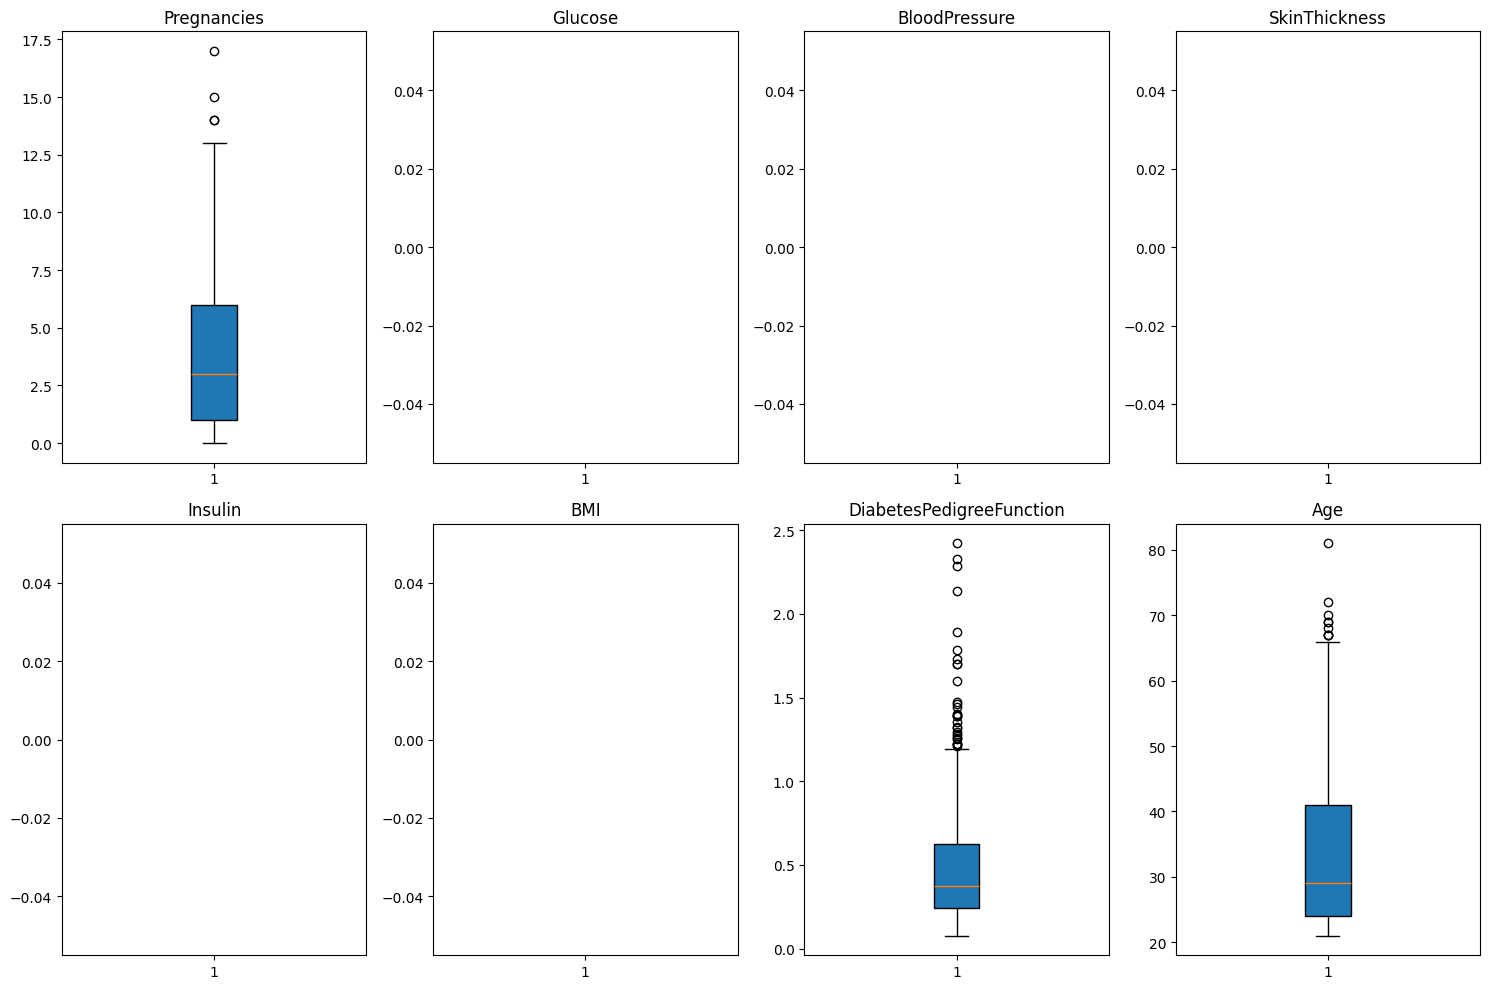

In [40]:
cols = df.drop(columns=["Outcome"]).columns

plt.figure(figsize=(15,10))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 4, i)   # 2 hàng, 4 cột (8 biến)
    plt.boxplot(df[col], patch_artist=True)
    plt.title(col)

plt.tight_layout()
plt.show()

**Nhận xét:**

&#8226;&nbsp;&nbsp; `Pregnancies` (số lần mang thai): phân phối lệch phải, nhiều giá trị thấp, một số ít bệnh nhân có trên 12–15 lần mang thai (ngoại lai).<br>
&#8226;&nbsp;&nbsp; `Glucose` (glucose): trung vị khoảng ~110, phần lớn nằm trong 100–150, có một số ngoại lai rất thấp (0) và cao (gần 200).<br>
&#8226;&nbsp;&nbsp; `BloodPressure` (huyết áp): trung vị khoảng 70, dữ liệu khá tập trung, nhưng có nhiều giá trị bất thường thấp (0) và cao trên 100.<br>
&#8226;&nbsp;&nbsp; `SkinThickness` (độ dày da): phân phối lệch, nhiều giá trị bằng 0 (ngoại lai hoặc dữ liệu thiếu).<br>
&#8226;&nbsp;&nbsp; `Insulin` (insulin test): cực kỳ lệch phải, nhiều giá trị 0, một số ngoại lai rất lớn (trên 800).<br>
&#8226;&nbsp;&nbsp; `BMI` (BMI): trung vị khoảng 30, phần lớn nằm trong 25–35, nhưng có nhiều ngoại lai (dưới 10 và trên 50).<br>
&#8226;&nbsp;&nbsp; `DiabetesPedigreeFunction` (diabetes pedigree): đa số nhỏ hơn 1, nhiều ngoại lai >2.<br>
&#8226;&nbsp;&nbsp; `Age` (tuổi): trung vị khoảng 30, tập trung ở nhóm 20–40 tuổi, một số ngoại lai trên 70–80.

#### b) Hiển thị nhiều tính chất

##### Scatter plot
Đây là biểu đồ phân tán dữ liệu theo một biến mục tiêu, các dấu chấm thể hiện sự phân tán. Dữ liệu tập trung càng nhiều thì có màu càng đậm và ngược lại.<br>

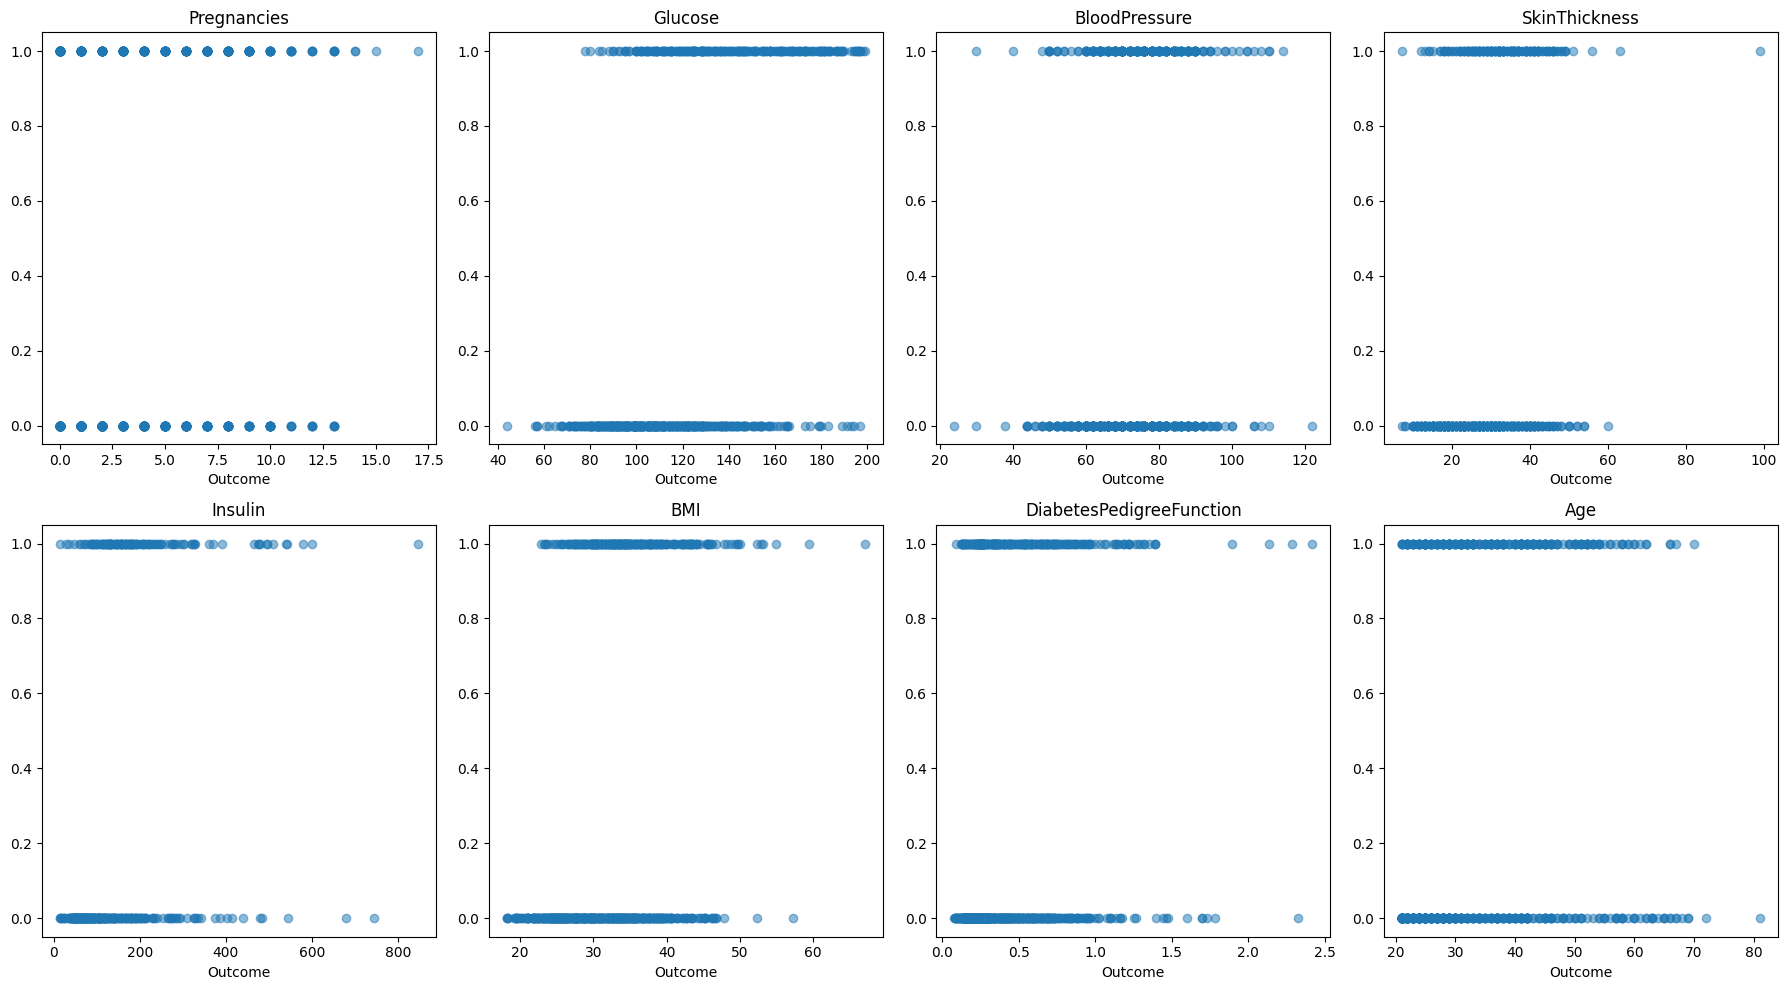

In [41]:
plt.figure(figsize=(18,10))

for i, col in enumerate(cols, 1):
    plt.subplot(2,4,i)
    plt.scatter(df[col], df['Outcome'], alpha=0.5)
    plt.title(col)
    plt.xlabel('Outcome')
plt.tight_layout()
plt.show()

**Nhận xét:**
- Người có mức Glucose cao có khả năng mắc tiểu đường cao nhất, cho thấy đây là yếu tố ảnh hưởng mạnh nhất.
- BMI và Age cũng có xu hướng tăng ở nhóm mắc bệnh, thể hiện vai trò đáng kể.
- Pregnancies có ảnh hưởng nhẹ, trong khi BloodPressure, SkinThickness, Insulin, và DiabetesPedigreeFunction không cho thấy sự khác biệt rõ ràng giữa hai nhóm Outcome.

##### Heatmap

<Axes: >

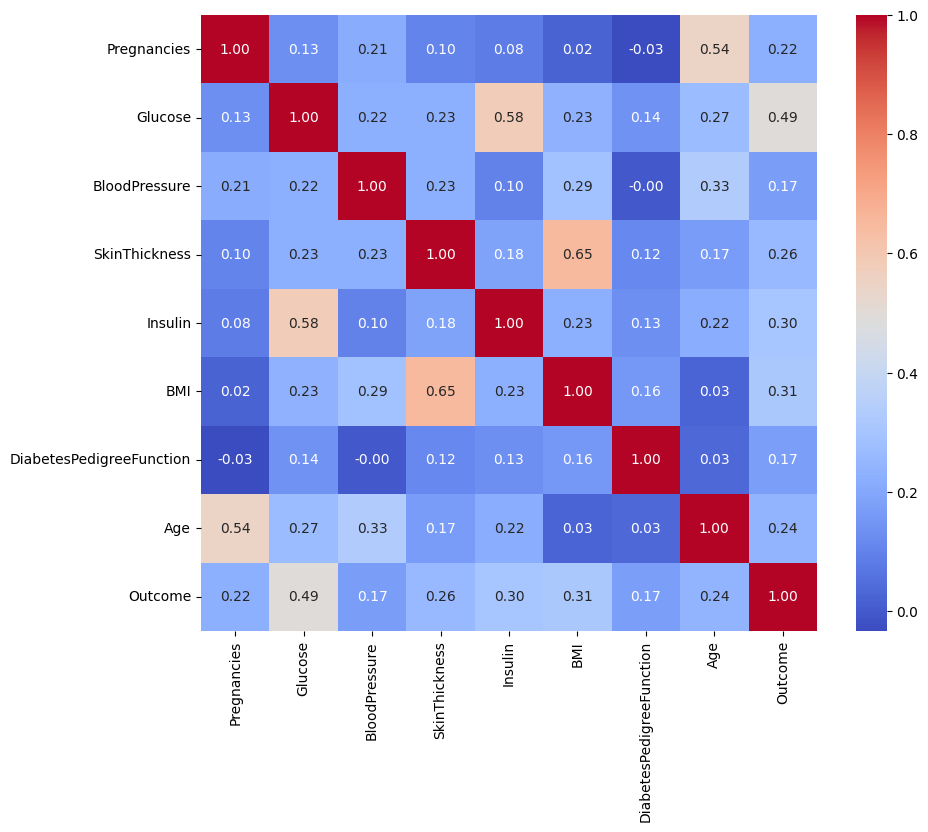

In [42]:
fig = plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True)